# پروژه کلاسی‌فیکیشن سرطان سینه (Breast Cancer Wisconsin Diagnostic)
EDA → پاکسازی → SMOTE → Hyperparameter Tuning → مدل‌سازی → ارزیابی (Accuracy, AUC, Cross Validation)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, roc_auc_score, accuracy_score)
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

## ۱. بارگذاری داده
همون فایل `data.csv` که استاد داده رو می‌خونیم (دیتاست Breast Cancer Wisconsin Diagnostic).

In [2]:
data = pd.read_csv('data.csv')
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
data.shape

(569, 33)

In [4]:
data.columns.tolist()

['id',
 'diagnosis',
 'radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'symmetry_mean',
 'fractal_dimension_mean',
 'radius_se',
 'texture_se',
 'perimeter_se',
 'area_se',
 'smoothness_se',
 'compactness_se',
 'concavity_se',
 'concave points_se',
 'symmetry_se',
 'fractal_dimension_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'smoothness_worst',
 'compactness_worst',
 'concavity_worst',
 'concave points_worst',
 'symmetry_worst',
 'fractal_dimension_worst',
 'Unnamed: 32']

In [5]:
data = data.drop(columns=['id', 'Unnamed: 32'])
data['target'] = data['diagnosis'].map({'M': 0, 'B': 1})
data = data.drop(columns=['diagnosis'])
data.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


**نکته:** `target = 0` یعنی بدخیم (malignant)، `target = 1` یعنی خوش‌خیم (benign) — دقیقاً همون قراردادی که تو نسخه‌ی استاندارد این دیتاست هم استفاده میشه.

In [6]:
data.shape

(569, 31)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   radius_mean              569 non-null    float64
 1   texture_mean             569 non-null    float64
 2   perimeter_mean           569 non-null    float64
 3   area_mean                569 non-null    float64
 4   smoothness_mean          569 non-null    float64
 5   compactness_mean         569 non-null    float64
 6   concavity_mean           569 non-null    float64
 7   concave points_mean      569 non-null    float64
 8   symmetry_mean            569 non-null    float64
 9   fractal_dimension_mean   569 non-null    float64
 10  radius_se                569 non-null    float64
 11  texture_se               569 non-null    float64
 12  perimeter_se             569 non-null    float64
 13  area_se                  569 non-null    float64
 14  smoothness_se            5

In [8]:
data.isnull().sum()

radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
target                     0
dtype: int64

In [9]:
data.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


## ۲. بررسی توزیع کلاس‌ها (Class Balance)

In [10]:
data['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

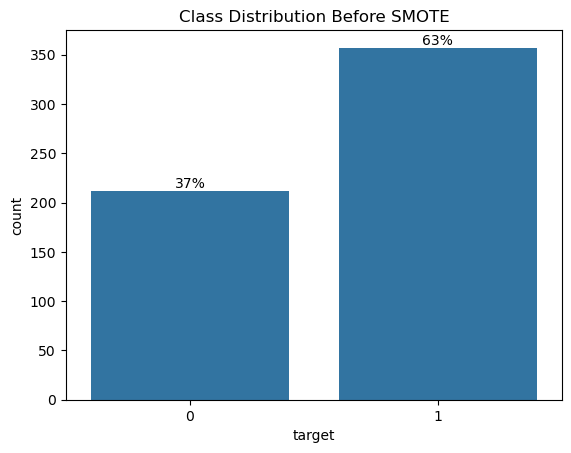

In [11]:
total = float(len(data))
ax = sb.countplot(x='target', data=data)
for i in ax.patches:
    height = i.get_height()
    ax.text(i.get_x()+i.get_width()/2., height+3,
            '{0:.0%}'.format(height/total), ha='center')
plt.title('Class Distribution Before SMOTE')
plt.show()

## ۳. ماتریس همبستگی و نمودارهای پیشرفته (EDA)

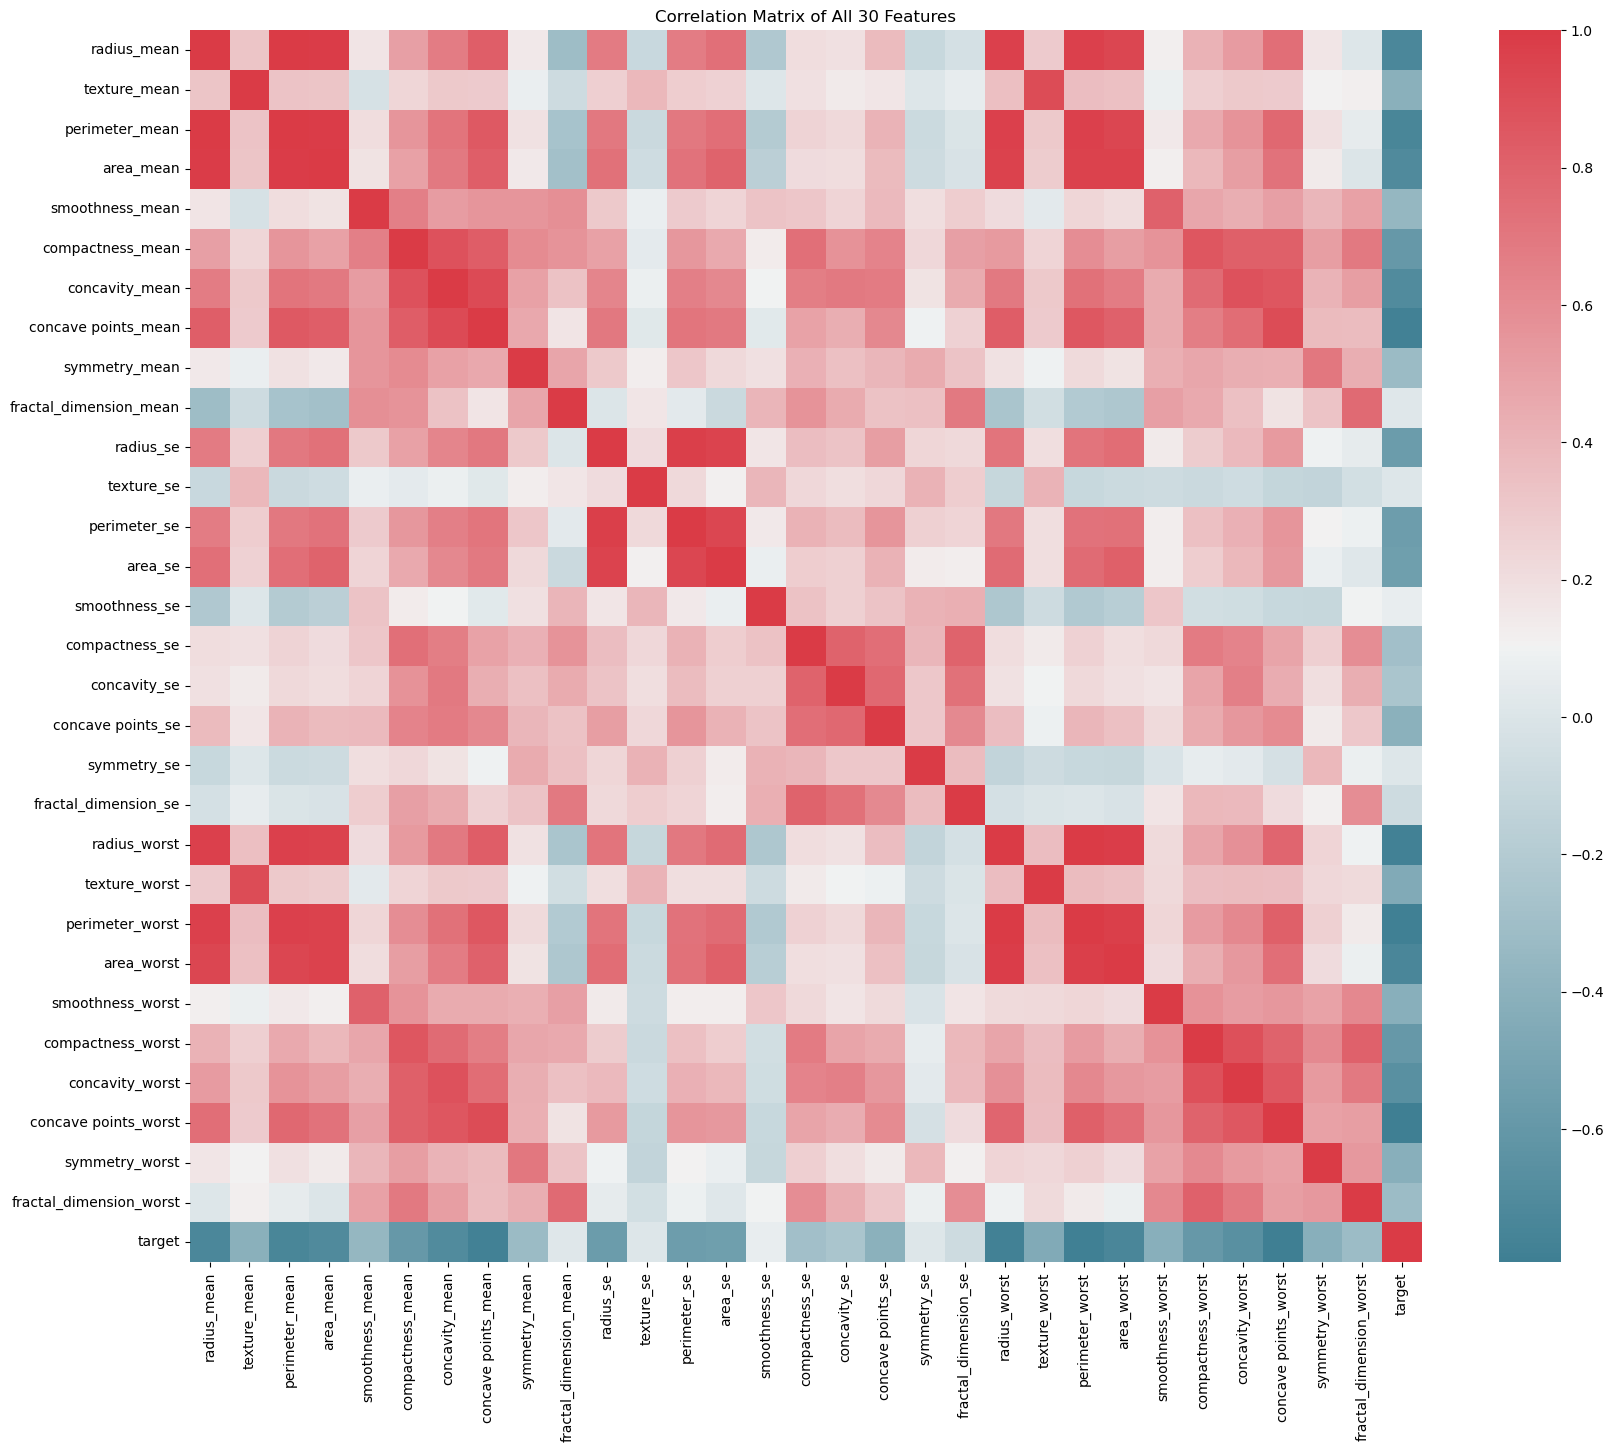

In [12]:
plt.figure(figsize=(20,16))
corr = data.corr()
sb.heatmap(corr, cmap=sb.diverging_palette(220,10,as_cmap=True), square=True)
plt.title('Correlation Matrix of All 30 Features')
plt.show()

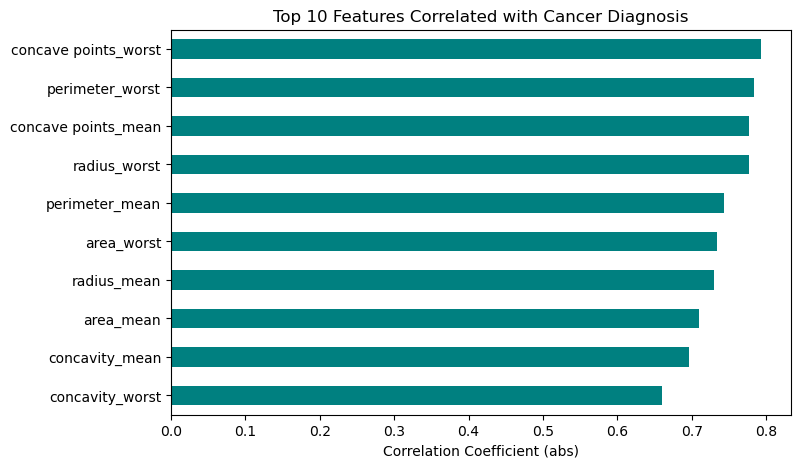

In [13]:
# ۱۰ ویژگی که بیشترین همبستگی رو با target دارن
top_corr = data.corr()['target'].abs().sort_values(ascending=False)[1:11]
plt.figure(figsize=(8,5))
top_corr.plot(kind='barh', color='teal')
plt.title('Top 10 Features Correlated with Cancer Diagnosis')
plt.xlabel('Correlation Coefficient (abs)')
plt.gca().invert_yaxis()
plt.show()

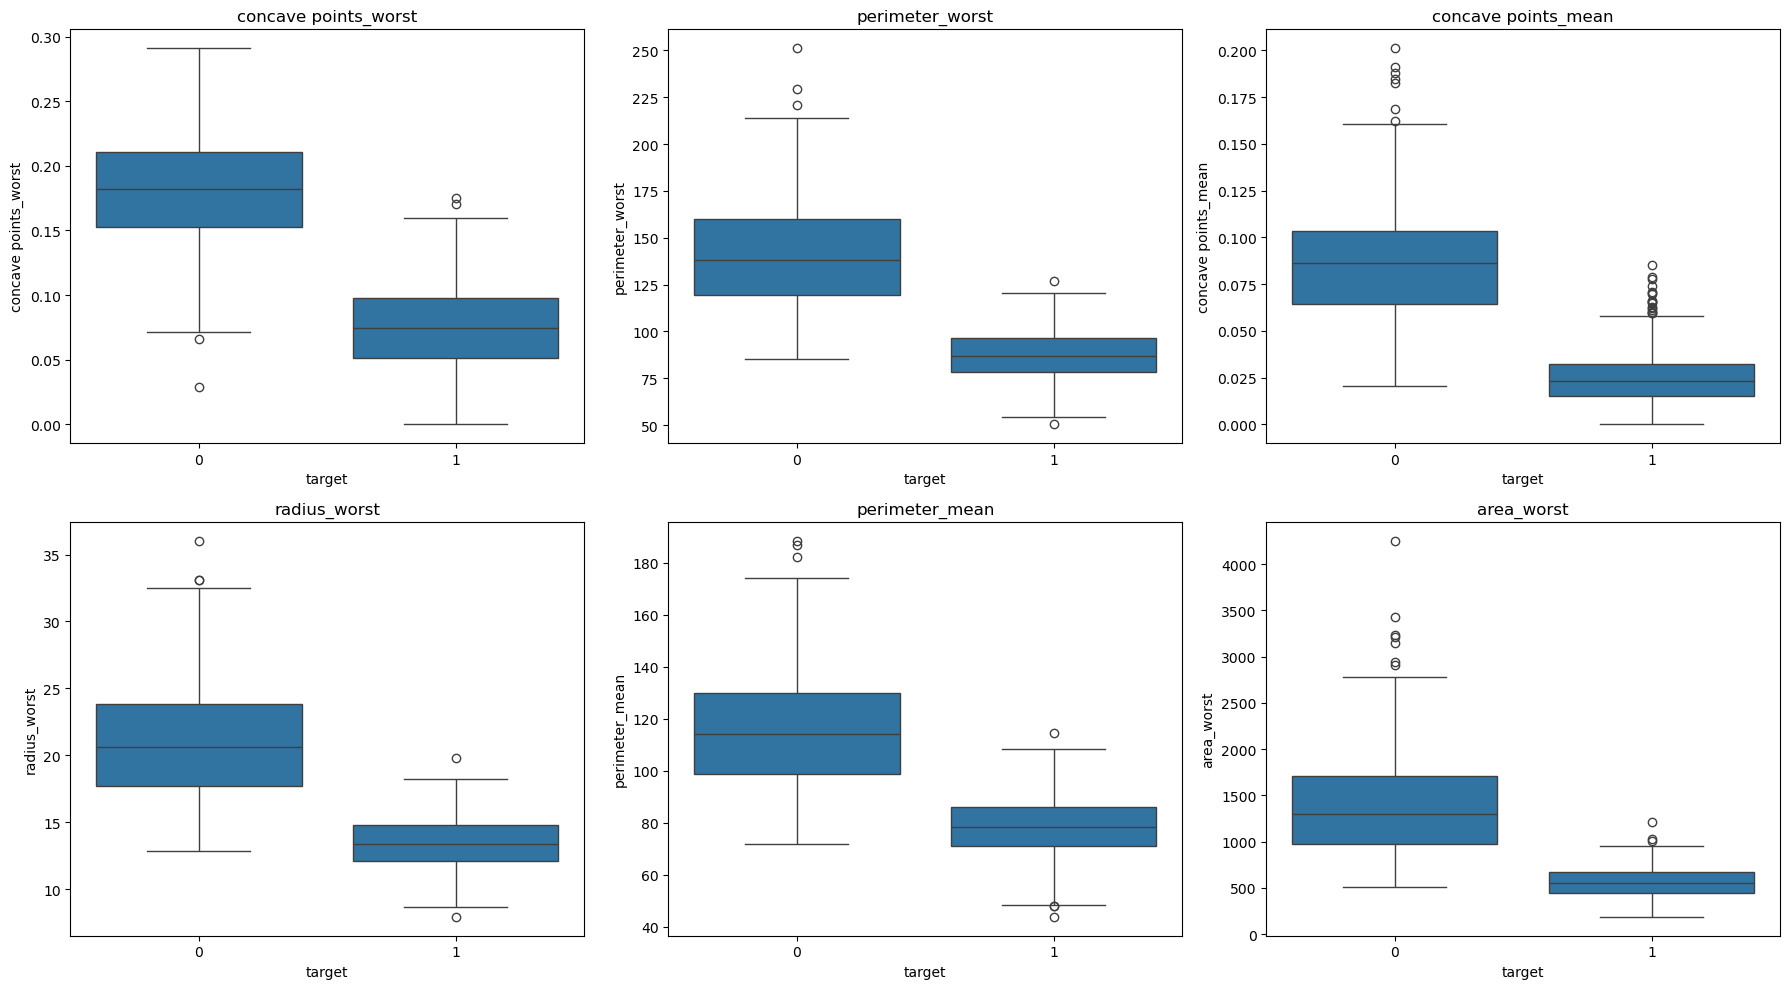

In [14]:
fig, axes = plt.subplots(2,3, figsize=(18,10))
top5 = top_corr.index[:6]
for ax, col in zip(axes.flatten(), top5):
    sb.boxplot(x='target', y=col, data=data, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

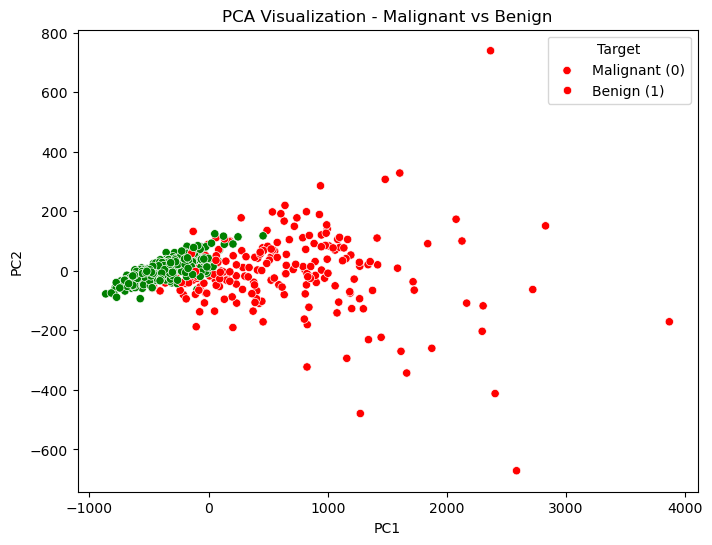

In [15]:
X_raw = data.drop(columns=['target'])
y_raw = data['target']

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_raw)

plt.figure(figsize=(8,6))
sb.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_raw, palette=['red','green'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Visualization - Malignant vs Benign')
plt.legend(title='Target', labels=['Malignant (0)', 'Benign (1)'])
plt.show()

## ۴. آماده‌سازی X و y

In [16]:
X = data.drop(columns=['target']).values
y = data['target'].values

## ۵. تقسیم Train/Test

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)

`stratify=y` باعث می‌شه نسبت کلاس‌ها تو train و test هم مثل داده‌ی اصلی حفظ بشه — مخصوصاً وقتی داده نامتوازنه مهمه.

## ۶. اعمال SMOTE (فقط روی داده‌ی Train)
**نکته‌ی خیلی مهم:** SMOTE فقط باید روی داده‌ی train اعمال بشه، نه کل داده و نه روی test! چون SMOTE نمونه‌های مصنوعی جدید می‌سازه؛ اگه رو کل داده اعمالش کنیم، ممکنه نمونه‌ی مصنوعی از یه نقطه بسازه و نسخه‌ی تقریباً مشابهش تو test بیفته → این باعث نشتی داده (Data Leakage) میشه و نتیجه‌ی ارزیابی رو غیرواقعی (بهتر از واقعیت) نشون میده.

In [18]:
print('قبل از SMOTE:', np.bincount(y_train))

smote = SMOTE(random_state=0)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('بعد از SMOTE:', np.bincount(y_train_sm))

قبل از SMOTE: [159 267]
بعد از SMOTE: [267 267]


SMOTE با استفاده از نزدیک‌ترین همسایه‌ها (KNN)، برای کلاس اقلیت (بدخیم) نمونه‌های مصنوعی جدید می‌سازه (نه اینکه فقط نمونه‌های موجود رو تکرار کنه) تا تعداد دو کلاس برابر بشه.

## ۷. پیدا کردن بهترین Hyperparameter با GridSearchCV

In [19]:
param_grid = {'C': [0.01, 0.1, 1, 5, 10, 20, 50]}

grid = GridSearchCV(LogisticRegression(solver='liblinear', random_state=0),
                     param_grid, cv=5, scoring='roc_auc')
grid.fit(X_train_sm, y_train_sm)

print('بهترین C:', grid.best_params_)
print('بهترین AUC روی cross validation:', grid.best_score_)

بهترین C: {'C': 50}
بهترین AUC روی cross validation: 0.9949672349458751


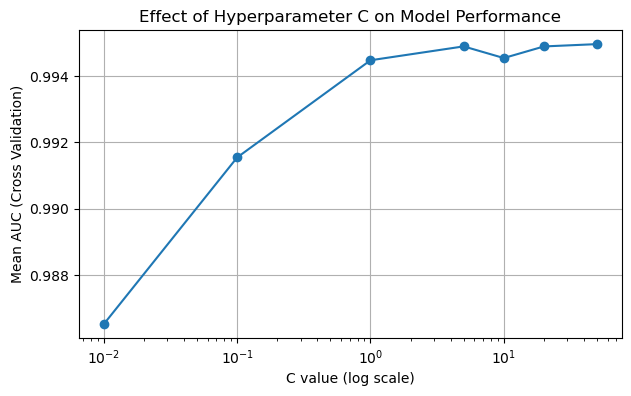

In [20]:
results_df = pd.DataFrame(grid.cv_results_)[['param_C','mean_test_score']]
plt.figure(figsize=(7,4))
plt.plot(results_df['param_C'], results_df['mean_test_score'], marker='o')
plt.xscale('log')
plt.xlabel('C value (log scale)')
plt.ylabel('Mean AUC (Cross Validation)')
plt.title('Effect of Hyperparameter C on Model Performance')
plt.grid(True)
plt.show()

این نمودار دقیقاً نشون می‌ده هر مقدار C چه تاثیری روی AUC داره — می‌تونی تو ارائه نشونش بدی، خیلی قابل فهمه.

## ۸. آموزش مدل نهایی با بهترین C

In [21]:
best_C = grid.best_params_['C']
model = LogisticRegression(solver='liblinear', C=best_C, random_state=0)
model.fit(X_train_sm, y_train_sm)

LogisticRegression(C=50, random_state=0, solver='liblinear')

## ۹. Cross Validation روی مدل نهایی

In [22]:
kf = KFold(10)
cv_scores = cross_val_score(model, X_train_sm, y_train_sm, cv=kf)
print('دقت هر Fold:', cv_scores)
print('میانگین دقت Cross Validation:', cv_scores.mean())

دقت هر Fold: [0.98148148 0.90740741 0.98148148 0.94444444 0.94339623 0.98113208
 0.96226415 0.98113208 0.96226415 0.98113208]
میانگین دقت Cross Validation: 0.9626135569531797


## ۱۰. پیش‌بینی و ارزیابی روی داده‌ی Test (بدون SMOTE، دست‌نخورده)

In [23]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print('Accuracy:', acc)
print('AUC:', auc)

Accuracy: 0.9370629370629371
AUC: 0.990146750524109


**چرا تست رو بدون SMOTE گذاشتیم؟** چون test باید دنیای واقعی رو شبیه‌سازی کنه، جایی که داده نامتوازنه. SMOTE فقط برای کمک به یادگیری بهتر مدل روی train استفاده میشه، نه برای قضاوت نهایی.

## ۱۱. نمودار ROC و AUC

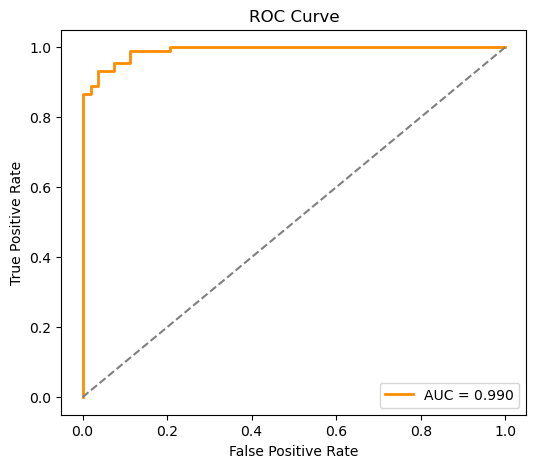

In [24]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}', color='darkorange', linewidth=2)
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## ۱۲. Confusion Matrix

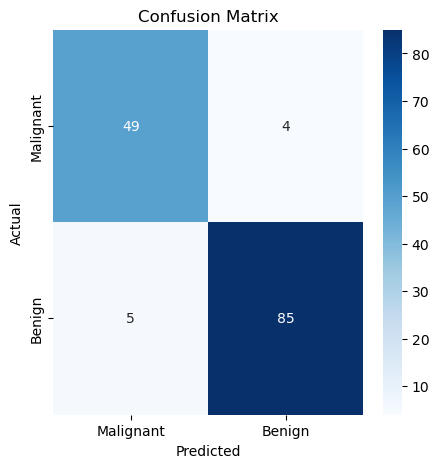

In [25]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5,5))
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## ۱۳. Classification Report

In [26]:
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

              precision    recall  f1-score   support

   Malignant       0.91      0.92      0.92        53
      Benign       0.96      0.94      0.95        90

    accuracy                           0.94       143
   macro avg       0.93      0.93      0.93       143
weighted avg       0.94      0.94      0.94       143



## ۱۴. جمع‌بندی نتایج (برای اسلاید یا ارائه)

In [27]:
summary = pd.DataFrame({
    'Metric': ['Accuracy', 'AUC', 'Cross Validation Mean', 'Best C'],
    'Value': [round(acc,4), round(auc,4), round(cv_scores.mean(),4), best_C]
})
summary

,Metric,Value
0,Accuracy,0.9371
1,AUC,0.9901
2,Cross Validation Mean,0.9626
3,Best C,50.0000
